# Assignment 3: Linear Models
#hi

In [1]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 79 (delta 29), reused 12 (delta 12), pack-reused 39 (from 2)
Receiving objects: 100% (79/79), 11.71 MiB | 13.00 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

**A model is called linear if it is linear in its parameters (coefficients β), meaning the coefficients only multiply  variables and are added together, and are not transformed (like not squared, exponentiated, etc). "Linear" refers to the parameters, not necessarily the inputs, so the model can still include nonlinear transformations of x (like x squared or log x) and remain linear.**

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

**The coefficient of a dummy variable represents the difference in the outcome between the group coded as 1 and the baseline group (coded as 0), which is captured by the intercept.**

3. Can linear regression be used for classification? Explain why, or why not.

**Linear regression can technically be used for classification by applying a threshold, but it is not appropriate because it predicts continuous values (not probabilities), can produce outputs outside 0-1, and does not model class boundaries as well.**

4. What are signs that your linear model is over-fitting?

**Signs of overfitting include low training error but high test/validation error, indicating the model fits the training data too closely and does not generalize well to new data.**


5. Clearly explain multi-colinearity using the two-stage least squares technique.

**Multicollinearity occurs when predictors are highly correlated, making coefficients unstable; using a two-stage approach, we first regress a collinear variable on others to isolate its unique (residual) component, then use that in the main regression to remove overlap and obtain more reliable estimates.**


6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

**Nonlinear relationships can be incorporated by transforming the input variables (like adding polynomial, logarithmic, or interaction terms) and including them as features in a linear regression model.**

7. What is the interpretation of the slope coefficient in a linear regression?

**The slope coefficient represents the change in the dependent variable y for a one-unit increase in x, holding all other variables constant.**

8. Compare the train/test split and $k$-fold cross validation.

**Train/test split evaluates a model using a single data split, while k-fold cross-validation repeatedly splits the data into k subsets, trains and tests k times, and averages the results to provide a more reliable estimate of model performance**

9. How is the $k$ in $k$-fold cross validation typically selected?

**The value of k is typically chosen as 5 or 10 to balance computational efficiency and reliable model evaluation.**

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [11]:
#Q2.1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm

df = pd.read_csv('./undergrad_ml_assignments/data/Q1_clean.csv')
df.columns = df.columns.str.strip()
df = df.rename(columns={"Neighbourhood": "Neighbourhood"})

                Price  Review Scores Rating
Neighbourhood                              
Manhattan      183.66                 91.80
Staten Island  146.17                 90.84
Brooklyn       127.75                 92.36
Queens          96.86                 91.55
Bronx           75.28                 91.65

Most expensive: Manhattan


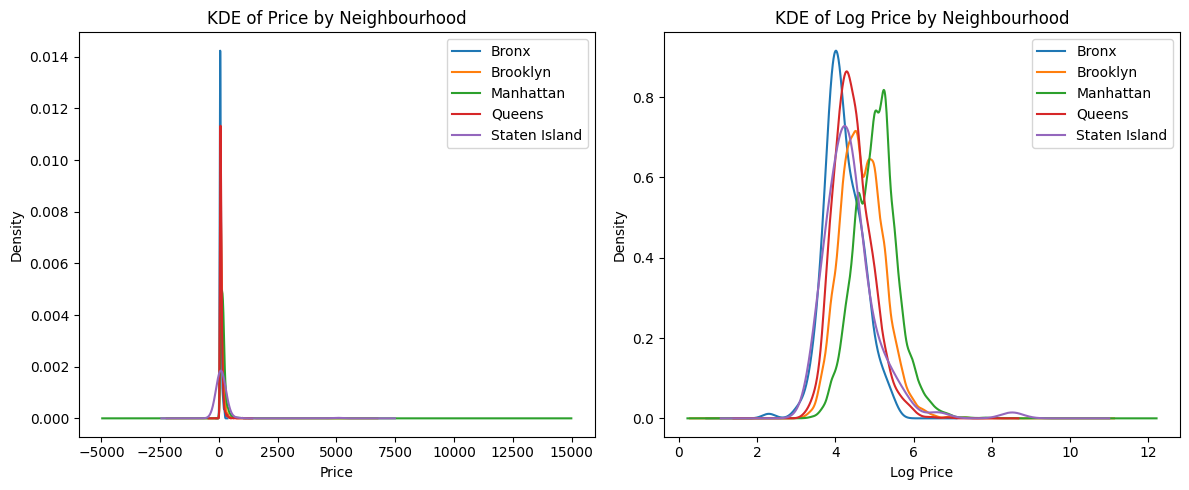

In [13]:
#Q2.1

#Average price and score by neighbourhood
summary = df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean().round(2)
print(summary.sort_values("Price", ascending=False))

#Most expensive borough
most_expensive = summary["Price"].idxmax()
print(f"\nMost expensive: {most_expensive}")

#KDE plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for hood, group in df.groupby("Neighbourhood"):
  group["Price"].plot.kde(ax=axes[0], label=hood)
  np.log(group["Price"]).plot.kde(ax=axes[1], label=hood)

axes[0].set_title("KDE of Price by Neighbourhood")
axes[0].set_xlabel("Price")
axes[0].legend()

axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].set_xlabel('Log Price')
axes[1].legend()

plt.tight_layout()
plt.show()

**Q2.1 Answer:**

**Manhattan is the most expensive borough. The raw price distribution is right-skewed, meaning a small number of very expensive listings pull the mean up. Taking the log compresses those large values, making the distribution more symmetric and approximately normal - which is a more useful shape for regression modeling.**

In [15]:
#Q2.2

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True).astype(int)
X = sm.add_constant(dummies)
y = df["Price"]

model2 = sm.OLS(y, X).fit()
print(model2.summary())

print("\nGroup means:")
print(df.groupby('Neighbourhood')['Price'].mean())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        15:14:14   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

**Q2.2 Answer:**

**The intercept is the Bronx's average price (reference category), and each coefficent is how much more or less expensive that borough is compared to the Bronx. This means the coefficients are just differences in group means - this can be verified by subtracting the Bronx mean from each other borough's mean in the Q2.1 table and the same numbers are outputted.**

In [16]:
#Q2.3

X3 = sm.add_constant(df["Review Scores Rating"])
model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        15:21:13   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

**Q2.3 Answer:**

**The slope coefficient is essentially saying that a one-point increase in Review Scores Rating is associated with a [coefficient] dollar change in Price per night on average.**

In [17]:
#Q2.4

X4 = sm.add_constant(pd.concat([dummies, df["Review Scores Rating"]], axis=1))
model4 = sm.OLS(y, X4).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        15:26:44   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

**Q2.4 Answer:**

**Once we control for neighbourhood, the slope on Review Scores Rating changes because we are now estimating the effects of ratings within each borough, removing the confounding effect of neighbourhood on both price and ratings. The neighbourhood coefficients also shift slightly since they now represent price differences holding rating constant rather than raw group means.**

In [18]:
#Q2.5

df["Rating"] = df["Review Scores Rating"]
X5 = sm.add_constant(
    pd.concat([dummies, df['Rating'],
               dummies.multiply(df['Rating'], axis=0)], axis=1)
)

model5 = sm.OLS(y, X5).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:45:22   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            22.6384    110.171      0.205

**Q2.5 Answer:**

**This model gives each neighbourhood its own slope for Review Scores Rating. If the interaction coefficients are small or insignificant, the relationship between ratings and price is roughly the same across all boroughs - if they differ a lot, ratings matter more in some neighbourhoods than others.**

In [19]:
#Q2.6

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X4_sk = pd.concat([dummies, df["Rating"]], axis=1).astype(float)
X5_sk = pd.concat([dummies, df["Rating"],
                  dummies.multiply(df['Rating'], axis=0)], axis=1).astype(float)

for name, X in [("Model 4 (neighbourhood + rating)", X4_sk),
                ("Model 5 (interactions)", X5_sk)]:

    scores = cross_val_score(LinearRegression(), X, y, cv=10,
                             scoring="neg_mean_squared_error")

    rsme = np.sqrt(-scores.mean())
    print(f"{name}: CV RSME = {rsme:.2f}")

Model 4 (neighbourhood + rating): CV RSME = 145.24
Model 5 (interactions): CV RSME = 146.02


**Q2.6 Answer:**

**Cross validation gives us an honest estimate of how well each model predicts on unseen data by comparing CV RSME scores - the lower the better. If the interaction model from Q2.5 has a similar or only slightly lower RSME than Q2.4, the added complexity of fitting separate slopes per neighbourhood isn't worth it and we should prefer the simpler model.**

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [21]:
df = pd.read_csv('./undergrad_ml_assignments/data/cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [22]:
df = pd.read_csv('./undergrad_ml_assignments/data/heart_hw.csv')
df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0
